In [ ]:
!pip install umap-learn

In [ ]:
# ============================================================
# MAPCT-v5 COMPLETE FIXED PIPELINE - GPU READY
# Addresses: Leakage, GAN instability, Retrieval, Generation
# ============================================================

# ============================================================
# SECTION 0: IMPORTS & DEVICE SETUP
# ============================================================
import os
import re
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)



Using device: cpu
DEVICE: cpu


In [ ]:
# ============================================================
# SECTION 1: DATA LOADING & NORMALIZATION
# ============================================================

# Load data
from google.colab import drive
drive.mount('/content/drive')

file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1, engine="openpyxl")
mech_df = pd.read_excel(file_path2, engine="openpyxl")

print(f"Loaded {len(clinic_df)} patients, {len(mech_df)} mechanism entries")

# Normalization functions
def normalize_drug_name(name):
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\s*\+\s*", ", ", name)
    name = re.sub(r"\s*,\s*", ", ", name)
    return name.strip()

def split_combo(combo):
    if not isinstance(combo, str):
        return []
    return [d.strip() for d in combo.split(",") if d.strip()]

def sort_drug_combo(combo):
    if not isinstance(combo, str):
        return ""
    drugs = sorted(d.strip() for d in combo.split(",") if d.strip())
    return ", ".join(drugs)

# Normalize clinic drug strings
clinic_df["merged_drugs_norm"] = (
    clinic_df["merged_drugs"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 4547 patients, 164 mechanism entries


In [ ]:
# ============================================================
# SECTION 2: LEAK-PROOF TRAIN/VAL/TEST SPLIT
# ============================================================

# ============================================================
# SECTION 2: LEAKAGE‑FREE SPLIT BY REGIMEN (GROUP‑BASED)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit

# Groups = unique drug combination strings (normalized)
groups = clinic_df["merged_drugs_norm"]

# First split: separate test set (20% of groups)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_val, idx_test = next(gss1.split(clinic_df, groups=groups))

# Second split: from remaining groups, take 20% for validation (→ 16% of total patients)
groups_train_val = groups.iloc[idx_train_val]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_rel, idx_val_rel = next(gss2.split(clinic_df.iloc[idx_train_val], groups=groups_train_val))

# Convert relative indices to original indices
idx_train = idx_train_val[idx_train_rel]
idx_val = idx_train_val[idx_val_rel]
# idx_test already defined

# Create dataframes
train_df = clinic_df.iloc[idx_train].copy()
val_df   = clinic_df.iloc[idx_val].copy()
test_df  = clinic_df.iloc[idx_test].copy()

print(f"Leakage‑free splits: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Sanity check: no drug combination appears in both train and test
train_combos = set(clinic_df.iloc[idx_train]["merged_drugs_norm"])
test_combos  = set(clinic_df.iloc[idx_test]["merged_drugs_norm"])
assert len(train_combos & test_combos) == 0, "❌ Leakage detected!"
print("✅ Verified: train and test have no common regimens.")

Splits: Train=3182, Val=455, Test=910


In [ ]:
# ============================================================
# SECTION 3: DRUG VOCABULARY (TRAIN ONLY)
# ============================================================

def build_drug_vocabulary(train_df):
    """Build drug vocabulary from training data ONLY"""
    all_drugs = set()
    for combo in train_df["merged_drugs_norm"]:
        for drug in split_combo(combo):
            all_drugs.add(drug)
    drug_to_idx = {drug: i for i, drug in enumerate(sorted(all_drugs))}
    idx_to_drug = {i: drug for drug, i in drug_to_idx.items()}
    return drug_to_idx, idx_to_drug, len(drug_to_idx)

def encode_regimen_multi_hot(combo, drug_to_idx):
    """Convert regimen to multi-hot vector"""
    vec = np.zeros(len(drug_to_idx), dtype=np.float32)
    for drug in split_combo(combo):
        if drug in drug_to_idx:
            vec[drug_to_idx[drug]] = 1.0
    return vec

# Filter validation/test to train vocabulary
def filter_to_train_vocab(combo, drug_to_idx):
    if not isinstance(combo, str):
        return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    filtered = [d for d in drugs if d in drug_to_idx]
    return ", ".join(sorted(filtered))

# Build vocabulary from train only
drug_to_idx, idx_to_drug, num_drugs = build_drug_vocabulary(train_df)
drug_vocab = list(drug_to_idx.keys())
print(f"Drug vocabulary size: {num_drugs}")

# Filter val/test to train vocabulary
val_df["merged_drugs_norm"] = val_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))
test_df["merged_drugs_norm"] = test_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))

# ============================================================
# SECTION 4: CLINICAL PREPROCESSING (FIT ON TRAIN ONLY)
# ============================================================

scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on train only
X_num_train = scaler.fit_transform(train_df[numeric_cols])
X_cat_train = ohe.fit_transform(train_df[categorical_cols])
X_train = np.hstack([X_num_train, X_cat_train])

# Transform val and test
X_num_val = scaler.transform(val_df[numeric_cols])
X_cat_val = ohe.transform(val_df[categorical_cols])
X_val = np.hstack([X_num_val, X_cat_val])

X_num_test = scaler.transform(test_df[numeric_cols])
X_cat_test = ohe.transform(test_df[categorical_cols])
X_test = np.hstack([X_num_test, X_cat_test])

print(f"Clinical feature dimension: {X_train.shape[1]}")

# ============================================================
# SECTION 5: MECHANISM EMBEDDINGS (TRAIN DRUGS ONLY)
# ============================================================

from sentence_transformers import SentenceTransformer

def build_mechanism_embeddings(train_drugs, mech_df, embed_dim=None):
    """Build mechanism embeddings for training drugs only"""

    # Normalize mechanism table
    mech_df["Drug Name Norm"] = mech_df["Drug Name"].astype(str).apply(normalize_drug_name).apply(sort_drug_combo)

    # Filter to training drugs only
    mech_df_filtered = mech_df[mech_df["Drug Name Norm"].isin(train_drugs)].copy()

    # Create mechanism text
    text_cols = ["Mechanisms", "Description", "Target IDs", "Pathway IDs", "ATC Code(s)"]

    def get_mechanism_text(row):
        parts = []
        for col in text_cols:
            if col in row and pd.notna(row[col]):
                parts.append(str(row[col]))
        return " | ".join(parts) if parts else row["Drug Name Norm"]

    mech_df_filtered["mech_text"] = mech_df_filtered.apply(get_mechanism_text, axis=1)

    # Generate embeddings
    model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    actual_embed_dim = model.get_sentence_embedding_dimension()
    print(f"   Model embedding dimension: {actual_embed_dim}")

    if embed_dim is None:
        embed_dim = actual_embed_dim

    embeddings = {}
    with torch.no_grad():
        for _, row in tqdm(mech_df_filtered.iterrows(), total=len(mech_df_filtered), desc="Generating mechanism embeddings"):
            drug = row["Drug Name Norm"]
            text = row["mech_text"]
            emb = model.encode(text, convert_to_tensor=True)
            if actual_embed_dim != embed_dim:
                projection = nn.Linear(actual_embed_dim, embed_dim).to(device)
                emb = projection(emb)
            embeddings[drug] = F.normalize(emb, dim=0).cpu()

    # Default for drugs without mechanism data
    default_emb = torch.zeros(embed_dim)
    drug_embeddings = {drug: embeddings.get(drug, default_emb) for drug in train_drugs}

    return drug_embeddings, embed_dim

# Build embeddings for training drugs only
train_drugs = set(drug_to_idx.keys())
drug_embeddings, embed_dim = build_mechanism_embeddings(train_drugs, mech_df, embed_dim=128)
print(f"Embedding dimension: {embed_dim}")
print(f"Built embeddings for {len(drug_embeddings)} drugs")




Drug vocabulary size: 160
Clinical feature dimension: 25


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_2890/3179089483.py:92: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  actual_embed_dim = model.get_sentence_embedding_dimension()


   Model embedding dimension: 384


Generating mechanism embeddings: 100%|██████████| 108/108 [00:06<00:00, 16.85it/s]

Embedding dimension: 128
Built embeddings for 160 drugs


In [ ]:
# ============================================================
# SECTION 6: REGIMEN MECHANISM TENSOR
# ============================================================

MAX_DRUGS = 10

def build_regimen_mechanism_tensor(combo, drug_embeddings, max_drugs=MAX_DRUGS, embed_dim=embed_dim):
    """Build mechanism tensor for a regimen (stacked drug embeddings)"""
    drugs = split_combo(combo)[:max_drugs]
    tensor = torch.zeros(max_drugs, embed_dim)

    for i, drug in enumerate(drugs):
        emb = drug_embeddings.get(drug, torch.zeros(embed_dim))
        tensor[i] = emb

    mask = torch.zeros(max_drugs, dtype=torch.bool)
    mask[:len(drugs)] = True
    return tensor, mask



In [ ]:
# ============================================================
# SECTION 7: DATASET CLASS
# ============================================================

class RegimenDataset(Dataset):
    def __init__(self, df, clinical_features, drug_to_idx, drug_embeddings, embed_dim=embed_dim):
        self.df = df.reset_index(drop=True)
        self.clinical_features = clinical_features
        self.drug_to_idx = drug_to_idx
        self.drug_embeddings = drug_embeddings
        self.embed_dim = embed_dim
        self.num_drugs = len(drug_to_idx)

        # Precompute multi-hot labels
        self.labels = []
        for _, row in self.df.iterrows():
            label = encode_regimen_multi_hot(row["merged_drugs_norm"], drug_to_idx)
            self.labels.append(label)

        # Precompute mechanism tensors
        self.mech_tensors = []
        self.mech_masks = []
        for _, row in self.df.iterrows():
            tensor, mask = build_regimen_mechanism_tensor(row["merged_drugs_norm"], drug_embeddings)
            self.mech_tensors.append(tensor)
            self.mech_masks.append(mask)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            'clinical': torch.tensor(self.clinical_features[idx], dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32),
            'mech_tensor': self.mech_tensors[idx],
            'mech_mask': self.mech_masks[idx]
        }

# Create datasets
train_dataset = RegimenDataset(train_df, X_train, drug_to_idx, drug_embeddings)
val_dataset = RegimenDataset(val_df, X_val, drug_to_idx, drug_embeddings)
test_dataset = RegimenDataset(test_df, X_test, drug_to_idx, drug_embeddings)

# Create dataloaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

# ============================================================
# SECTION 8: MODEL ARCHITECTURE
# ============================================================

class ClinicalEncoder(nn.Module):
    """Encodes clinical features into latent space"""
    def __init__(self, input_dim, latent_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

class RegimenMechanismEncoder(nn.Module):
    """Encodes regimen mechanism tensor into latent space"""
    def __init__(self, embed_dim=embed_dim, latent_dim=128, n_heads=4, n_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(embed_dim, latent_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim, nhead=n_heads, batch_first=True, dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.pool_proj = nn.Linear(latent_dim, latent_dim)

    def forward(self, mech_tensor, mask):
        x = self.input_proj(mech_tensor)
        x = self.transformer(x, src_key_padding_mask=~mask)
        mask_expanded = mask.unsqueeze(-1).float()
        pooled = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        return F.normalize(self.pool_proj(pooled), dim=1)

class DrugDecoder(nn.Module):
    """Decodes latent to drug multi-hot predictions"""
    def __init__(self, latent_dim=128, num_drugs=None, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_drugs)
        )

    def forward(self, z):
        return self.net(z)

class RegimenGenerator(nn.Module):
    """GAN Generator: creates regimen latents from clinical latents + noise"""
    def __init__(self, latent_dim=128, noise_dim=32, hidden_dim=256):
        super().__init__()
        self.noise_dim = noise_dim  # FIXED: store noise_dim
        self.net = nn.Sequential(
            nn.Linear(latent_dim + noise_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, latent_dim)
        )

    def forward(self, z_clin):
        noise = torch.randn(z_clin.size(0), self.noise_dim, device=z_clin.device)  # FIXED: use self.noise_dim
        z = torch.cat([z_clin, noise], dim=1)
        return F.normalize(self.net(z), dim=1)

class RegimenDiscriminator(nn.Module):
    """GAN Discriminator: distinguishes real vs fake regimen latents"""
    def __init__(self, latent_dim=128, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, z):
        return self.net(z)


Train batches: 50, Val batches: 8, Test batches: 15


In [ ]:
# ============================================================
# SECTION 9: LOSS FUNCTIONS
# ============================================================

def contrastive_loss(z1, z2, temperature=0.07):
    """InfoNCE contrastive loss between two latent spaces"""
    logits = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_fwd = F.cross_entropy(logits, labels)
    loss_rev = F.cross_entropy(logits.T, labels)
    return (loss_fwd + loss_rev) / 2

# ============================================================
# SECTION 10: TRAINER CLASS
# ============================================================

class MAPCTv5Trainer:
    def __init__(self, clinical_encoder, regimen_encoder, drug_decoder,
                 generator, discriminator, device, drug_vocab, drug_to_idx):
        self.clinical_encoder = clinical_encoder.to(device)
        self.regimen_encoder = regimen_encoder.to(device)
        self.drug_decoder = drug_decoder.to(device)
        self.generator = generator.to(device)
        self.discriminator = discriminator.to(device)
        self.device = device
        self.drug_vocab = drug_vocab
        self.drug_to_idx = drug_to_idx
        self.num_drugs = len(drug_vocab)

        # Optimizers
        self.opt_enc = torch.optim.Adam(
            list(self.clinical_encoder.parameters()) + list(self.regimen_encoder.parameters()),
            lr=1e-3, weight_decay=1e-5
        )
        self.opt_dec = torch.optim.Adam(self.drug_decoder.parameters(), lr=1e-3, weight_decay=1e-5)
        self.opt_G = torch.optim.Adam(self.generator.parameters(), lr=1e-4, weight_decay=1e-5)
        self.opt_D = torch.optim.Adam(self.discriminator.parameters(), lr=1e-4, weight_decay=1e-5)

        # Loss weights
        self.alpha_contrast = 0.3
        self.beta_drug = 1.0

        # Metrics tracking
        self.train_history = {'loss': [], 'contrast': [], 'drug': [], 'gan_d': [], 'gan_g': []}

    def eval(self):
        self.clinical_encoder.eval()
        self.regimen_encoder.eval()
        self.drug_decoder.eval()
        self.generator.eval()
        self.discriminator.eval()
        return self

    def train(self):
        self.clinical_encoder.train()
        self.regimen_encoder.train()
        self.drug_decoder.train()
        self.generator.train()
        self.discriminator.train()
        return self

    def train_epoch(self, train_loader):
        self.clinical_encoder.train()
        self.regimen_encoder.train()
        self.drug_decoder.train()
        self.generator.train()
        self.discriminator.train()

        total_loss = 0
        total_contrast = 0
        total_drug = 0
        total_d = 0
        total_g = 0

        for batch in train_loader:
            clinical = batch['clinical'].to(self.device)
            labels = batch['label'].to(self.device)
            mech_tensor = batch['mech_tensor'].to(self.device)
            mech_mask = batch['mech_mask'].to(self.device)

            # ===== ENCODER TRAINING =====
            z_clin = self.clinical_encoder(clinical)
            z_regimen = self.regimen_encoder(mech_tensor, mech_mask)

            loss_contrast = contrastive_loss(z_clin, z_regimen)

            drug_logits = self.drug_decoder(z_clin)
            loss_drug = F.binary_cross_entropy_with_logits(drug_logits, labels)

            loss_enc = self.alpha_contrast * loss_contrast + self.beta_drug * loss_drug

            self.opt_enc.zero_grad()
            self.opt_dec.zero_grad()
            loss_enc.backward()
            torch.nn.utils.clip_grad_norm_(self.clinical_encoder.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(self.regimen_encoder.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(self.drug_decoder.parameters(), 1.0)
            self.opt_enc.step()
            self.opt_dec.step()

            # ===== GAN TRAINING =====
            z_clin_detached = z_clin.detach()
            z_real = z_regimen.detach()
            z_fake = self.generator(z_clin_detached)

            # Train Discriminator
            d_real = self.discriminator(z_real)
            d_fake = self.discriminator(z_fake)

            loss_d = F.binary_cross_entropy_with_logits(d_real, torch.ones_like(d_real)) + \
                     F.binary_cross_entropy_with_logits(d_fake, torch.zeros_like(d_fake))
            loss_d = loss_d / 2

            self.opt_D.zero_grad()
            loss_d.backward()
            self.opt_D.step()

            # Train Generator
            z_fake = self.generator(z_clin_detached)
            d_fake = self.discriminator(z_fake)
            loss_g = F.binary_cross_entropy_with_logits(d_fake, torch.ones_like(d_fake))

            self.opt_G.zero_grad()
            loss_g.backward()
            self.opt_G.step()

            # Accumulate
            total_loss += loss_enc.item()
            total_contrast += loss_contrast.item()
            total_drug += loss_drug.item()
            total_d += loss_d.item()
            total_g += loss_g.item()

        n_batches = len(train_loader)
        return {
            'loss': total_loss / n_batches,
            'contrast': total_contrast / n_batches,
            'drug': total_drug / n_batches,
            'gan_d': total_d / n_batches,
            'gan_g': total_g / n_batches
        }

    def validate(self, val_loader):
        self.clinical_encoder.eval()
        self.regimen_encoder.eval()
        self.drug_decoder.eval()

        total_contrast = 0
        total_drug_acc = 0

        with torch.no_grad():
            for batch in val_loader:
                clinical = batch['clinical'].to(self.device)
                labels = batch['label'].to(self.device)
                mech_tensor = batch['mech_tensor'].to(self.device)
                mech_mask = batch['mech_mask'].to(self.device)

                z_clin = self.clinical_encoder(clinical)
                z_regimen = self.regimen_encoder(mech_tensor, mech_mask)

                loss_contrast = contrastive_loss(z_clin, z_regimen)
                total_contrast += loss_contrast.item()

                drug_logits = self.drug_decoder(z_clin)
                drug_probs = torch.sigmoid(drug_logits)
                preds = (drug_probs > 0.5).float()
                total_drug_acc += (preds == labels).float().mean().item()

        n_batches = len(val_loader)
        return {
            'contrast_loss': total_contrast / n_batches,
            'drug_accuracy': total_drug_acc / n_batches
        }

    def train(self, train_loader, val_loader, epochs=50, patience=10):
        best_val_loss = float('inf')
        patience_counter = 0

        for epoch in range(epochs):
            train_metrics = self.train_epoch(train_loader)
            val_metrics = self.validate(val_loader)

            self.train_history['loss'].append(train_metrics['loss'])
            self.train_history['contrast'].append(train_metrics['contrast'])
            self.train_history['drug'].append(train_metrics['drug'])
            self.train_history['gan_d'].append(train_metrics['gan_d'])
            self.train_history['gan_g'].append(train_metrics['gan_g'])

            if (epoch + 1) % 5 == 0:
                print(f"\nEpoch {epoch+1}/{epochs}")
                print(f"  Train - Loss: {train_metrics['loss']:.4f}, Contrast: {train_metrics['contrast']:.4f}, Drug: {train_metrics['drug']:.4f}")
                print(f"  Train - GAN: D={train_metrics['gan_d']:.4f}, G={train_metrics['gan_g']:.4f}")
                print(f"  Valid - Contrast: {val_metrics['contrast_loss']:.4f}, Drug Acc: {val_metrics['drug_accuracy']:.4f}")

            if val_metrics['contrast_loss'] < best_val_loss:
                best_val_loss = val_metrics['contrast_loss']
                patience_counter = 0
                self.save_checkpoint('best_model.pt')
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        return self.train_history

    def save_checkpoint(self, path):
        torch.save({
            'clinical_encoder': self.clinical_encoder.state_dict(),
            'regimen_encoder': self.regimen_encoder.state_dict(),
            'drug_decoder': self.drug_decoder.state_dict(),
            'generator': self.generator.state_dict(),
            'discriminator': self.discriminator.state_dict(),
        }, path)

    def load_checkpoint(self, path):
        checkpoint = torch.load(path, map_location=self.device)
        self.clinical_encoder.load_state_dict(checkpoint['clinical_encoder'])
        self.regimen_encoder.load_state_dict(checkpoint['regimen_encoder'])
        self.drug_decoder.load_state_dict(checkpoint['drug_decoder'])
        self.generator.load_state_dict(checkpoint['generator'])
        self.discriminator.load_state_dict(checkpoint['discriminator'])





In [ ]:
# ============================================================
# SECTION 11: EVALUATION FUNCTIONS
# ============================================================

def evaluate_drug_predictions(model, test_loader, drug_vocab, threshold=0.3):
    """Evaluate drug-level predictions using multi-label metrics"""
    all_preds = []
    all_labels = []

    model.clinical_encoder.eval()
    model.drug_decoder.eval()

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            labels = batch['label'].cpu().numpy()

            z_clin = model.clinical_encoder(clinical)
            logits = model.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(np.float32)

            all_preds.extend(preds)
            all_labels.extend(labels)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    results = {
        'precision': precision_score(all_labels, all_preds, average='micro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='micro', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='micro', zero_division=0),
        'accuracy': accuracy_score(all_labels.flatten(), all_preds.flatten())
    }
    return results

def predict_drugs(clinical_encoder, drug_decoder, clinical_tensor, drug_vocab, threshold=0.3):
    """Predict individual drugs for a patient"""
    clinical_encoder.eval()
    drug_decoder.eval()

    with torch.no_grad():
        z_clin = clinical_encoder(clinical_tensor)
        logits = drug_decoder(z_clin)
        probs = torch.sigmoid(logits).cpu().numpy().squeeze()

    predictions = [(drug_vocab[i], probs[i]) for i in range(len(probs)) if probs[i] > threshold]
    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions



# ============================================================
# SECTION 12: MAIN PIPELINE
# ============================================================

def run_full_pipeline(clinic_df, mech_df, numeric_cols, categorical_cols):
    """Complete MAPCT-v5 pipeline"""

    print("="*60)
    print("MAPCT-v5 FULL PIPELINE")
    print("="*60)

    # Step 1: Normalize drug names
    print("\n1. Normalizing drug names...")
    clinic_df["merged_drugs_norm"] = (
        clinic_df["merged_drugs"]
        .astype(str)
        .apply(normalize_drug_name)
        .apply(sort_drug_combo)
    )

    # Step 2: Create leak-proof splits
    print("\n2. Creating train/val/test splits...")
    train_idx, val_idx, test_idx = create_leakproof_splits(clinic_df)

    train_df = clinic_df.iloc[train_idx].copy()
    val_df = clinic_df.iloc[val_idx].copy()
    test_df = clinic_df.iloc[test_idx].copy()

    print(f"   Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

    # Step 3: Build drug vocabulary from train only
    print("\n3. Building drug vocabulary...")
    drug_to_idx, idx_to_drug, num_drugs = build_drug_vocabulary(train_df)
    drug_vocab = list(drug_to_idx.keys())
    print(f"   Vocabulary size: {num_drugs}")

    # Filter val/test to train vocabulary
    val_df["merged_drugs_norm"] = val_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))
    test_df["merged_drugs_norm"] = test_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))

    # Step 4: Build mechanism embeddings
    print("\n4. Building mechanism embeddings...")
    train_drugs = set(drug_to_idx.keys())
    drug_embeddings, embed_dim = build_mechanism_embeddings(train_drugs, mech_df, embed_dim=128)
    print(f"   Embedding dimension: {embed_dim}")

    # Step 5: Clinical preprocessing (fit on train only)
    print("\n5. Clinical preprocessing...")
    scaler = StandardScaler()
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    X_num_train = scaler.fit_transform(train_df[numeric_cols])
    X_cat_train = ohe.fit_transform(train_df[categorical_cols])
    X_train = np.hstack([X_num_train, X_cat_train])

    X_num_val = scaler.transform(val_df[numeric_cols])
    X_cat_val = ohe.transform(val_df[categorical_cols])
    X_val = np.hstack([X_num_val, X_cat_val])

    X_num_test = scaler.transform(test_df[numeric_cols])
    X_cat_test = ohe.transform(test_df[categorical_cols])
    X_test = np.hstack([X_num_test, X_cat_test])

    # Step 6: Create datasets
    print("\n6. Creating datasets...")
    train_dataset = RegimenDataset(train_df, X_train, drug_to_idx, drug_embeddings, embed_dim)
    val_dataset = RegimenDataset(val_df, X_val, drug_to_idx, drug_embeddings, embed_dim)
    test_dataset = RegimenDataset(test_df, X_test, drug_to_idx, drug_embeddings, embed_dim)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    # Step 7: Initialize models
    print("\n7. Initializing models...")
    clinical_encoder = ClinicalEncoder(input_dim=X_train.shape[1], latent_dim=128).to(device)
    regimen_encoder = RegimenMechanismEncoder(embed_dim=embed_dim, latent_dim=128).to(device)
    drug_decoder = DrugDecoder(latent_dim=128, num_drugs=num_drugs).to(device)
    generator = RegimenGenerator(latent_dim=128).to(device)
    discriminator = RegimenDiscriminator(latent_dim=128).to(device)

    # Step 8: Train
    print("\n8. Training...")
    trainer = MAPCTv5Trainer(
        clinical_encoder, regimen_encoder, drug_decoder,
        generator, discriminator, device, drug_vocab, drug_to_idx
    )

    history = trainer.train(train_loader, val_loader, epochs=50, patience=10)

    # Step 9: Evaluate drug predictions
    print("\n9. Evaluating drug-level predictions...")
    drug_metrics = evaluate_drug_predictions(trainer, test_loader, drug_vocab, threshold=0.3)

    print("\n" + "="*60)
    print("RESULTS:")
    print("="*60)
    print(f"Drug Prediction Metrics (micro-average):")
    print(f"  Precision: {drug_metrics['precision']:.4f}")
    print(f"  Recall:    {drug_metrics['recall']:.4f}")
    print(f"  F1-Score:  {drug_metrics['f1']:.4f}")
    print(f"  Accuracy:  {drug_metrics['accuracy']:.4f}")

    return trainer, scaler, ohe, drug_vocab, drug_to_idx, train_df, val_df, test_df, train_loader, test_loader, drug_embeddings


# ============================================================
# SECTION 13: VISUALIZATION FUNCTIONS (COMPLETE)
# ============================================================

def visualize_mechanism_embeddings(drug_embeddings, drug_vocab, top_n=50):
    """Visualize mechanism embeddings using PCA and t-SNE"""
    print("\n" + "="*70)
    print("🔬 MECHANISM EMBEDDINGS VISUALIZATION")
    print("="*70)

    # Filter to drugs that have embeddings
    drugs_with_emb = [d for d in drug_vocab if d in drug_embeddings]
    drugs_with_emb = drugs_with_emb[:top_n]

    if len(drugs_with_emb) < 2:
        print("Not enough drugs with embeddings to visualize")
        return

    # Create embedding matrix
    emb_matrix = torch.stack([drug_embeddings[d] for d in drugs_with_emb]).numpy()

    # PCA
    print("\n📊 Computing PCA...")
    pca = PCA(n_components=2, random_state=SEED)
    emb_pca = pca.fit_transform(emb_matrix)

    # t-SNE
    print("📊 Computing t-SNE...")
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(drugs_with_emb)-1))
    emb_tsne = tsne.fit_transform(emb_matrix)

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # PCA Plot
    axes[0].scatter(emb_pca[:, 0], emb_pca[:, 1], alpha=0.7, s=100)
    for i, drug in enumerate(drugs_with_emb):
        axes[0].annotate(drug, (emb_pca[i, 0], emb_pca[i, 1]), fontsize=8, alpha=0.7)
    axes[0].set_title(f'PCA of Mechanism Embeddings')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].grid(True, alpha=0.3)

    # t-SNE Plot
    axes[1].scatter(emb_tsne[:, 0], emb_tsne[:, 1], alpha=0.7, s=100)
    for i, drug in enumerate(drugs_with_emb):
        axes[1].annotate(drug, (emb_tsne[i, 0], emb_tsne[i, 1]), fontsize=8, alpha=0.7)
    axes[1].set_title('t-SNE of Mechanism Embeddings')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return emb_matrix, drugs_with_emb


def inspect_drug_mechanism_text(mech_df, drug_name):
    """Display mechanism text for a specific drug"""
    print("\n" + "="*70)
    print(f"🔬 MECHANISM INFORMATION FOR: {drug_name}")
    print("="*70)

    drug_norm = normalize_drug_name(drug_name)
    row = mech_df[mech_df["Drug Name Norm"] == drug_norm]

    if len(row) == 0:
        print(f"❌ No mechanism data found for {drug_name}")
        return None

    row = row.iloc[0]
    print(f"\n📋 Drug Name: {row['Drug Name']}")

    mech_cols = ["Mechanisms", "Description", "Target IDs", "ATC Code(s)"]
    for col in mech_cols:
        if col in row and pd.notna(row[col]):
            print(f"\n📌 {col}:")
            print(f"   {str(row[col])[:200]}...")

    return row


def compare_drug_embeddings(drug_embeddings, drug1, drug2):
    """Compare two drugs by their mechanism embeddings"""
    print("\n" + "="*70)
    print(f"🔬 COMPARING: {drug1} vs {drug2}")
    print("="*70)

    drug1_norm = normalize_drug_name(drug1)
    drug2_norm = normalize_drug_name(drug2)

    if drug1_norm not in drug_embeddings:
        print(f"❌ {drug1} not found in embeddings")
        return None
    if drug2_norm not in drug_embeddings:
        print(f"❌ {drug2} not found in embeddings")
        return None

    emb1 = drug_embeddings[drug1_norm]
    emb2 = drug_embeddings[drug2_norm]
    similarity = torch.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

    print(f"\n🎯 Cosine Similarity: {similarity:.4f}")
    if similarity > 0.7:
        print("   Interpretation: VERY SIMILAR mechanisms")
    elif similarity > 0.5:
        print("   Interpretation: MODERATELY similar")
    else:
        print("   Interpretation: VERY DIFFERENT mechanisms")

    return similarity


def find_similar_drugs_by_mechanism(drug_embeddings, drug_name, drug_vocab, top_k=10):
    """Find drugs with similar mechanism embeddings"""
    print("\n" + "="*70)
    print(f"🔬 DRUGS SIMILAR TO: {drug_name}")
    print("="*70)

    drug_norm = normalize_drug_name(drug_name)
    if drug_norm not in drug_embeddings:
        print(f"❌ {drug_name} not found")
        return []

    target_emb = drug_embeddings[drug_norm]
    similarities = []

    for drug in drug_vocab:
        if drug in drug_embeddings and drug != drug_norm:
            sim = torch.cosine_similarity(target_emb.unsqueeze(0), drug_embeddings[drug].unsqueeze(0)).item()
            similarities.append((drug, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop {top_k} similar drugs:")
    for i, (drug, sim) in enumerate(similarities[:top_k], 1):
        quality = "🟢" if sim > 0.7 else "🟡" if sim > 0.5 else "🔴"
        print(f"  {i:2}. {quality} {drug:<30} {sim:.4f}")

    return similarities[:top_k]


def visualize_drug_clusters(drug_embeddings, drug_vocab, drug_groups=None, top_n=100):
    """Visualize drug clusters with optional grouping"""
    print("\n" + "="*70)
    print("🔬 DRUG CLUSTER VISUALIZATION")
    print("="*70)

    drugs_with_emb = [d for d in drug_vocab if d in drug_embeddings][:top_n]
    if len(drugs_with_emb) < 2:
        print("Not enough drugs to visualize")
        return

    emb_matrix = torch.stack([drug_embeddings[d] for d in drugs_with_emb]).numpy()
    pca = PCA(n_components=2, random_state=SEED)
    emb_pca = pca.fit_transform(emb_matrix)

    plt.figure(figsize=(14, 10))

    if drug_groups:
        colors = []
        for drug in drugs_with_emb:
            found = False
            for group_name, group_drugs in drug_groups.items():
                if any(gd in drug.lower() for gd in [g.lower() for g in group_drugs]):
                    colors.append(group_name)
                    found = True
                    break
            if not found:
                colors.append('Other')

        unique_groups = list(set(colors))
        color_map = plt.cm.tab10(np.linspace(0, 1, len(unique_groups)))
        for i, group in enumerate(unique_groups):
            idx = [j for j, c in enumerate(colors) if c == group]
            plt.scatter(emb_pca[idx, 0], emb_pca[idx, 1], label=group, alpha=0.7, s=80)
    else:
        plt.scatter(emb_pca[:, 0], emb_pca[:, 1], alpha=0.7, s=80)

    # Label some drugs
    for i, drug in enumerate(drugs_with_emb[:30]):
        plt.annotate(drug, (emb_pca[i, 0], emb_pca[i, 1]), fontsize=8, alpha=0.7)

    plt.title('Drug Mechanism Clusters')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    if drug_groups:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    return emb_pca, drugs_with_emb


def analyze_drug_mechanism_similarity_matrix(drug_embeddings, drug_vocab, top_n=20):
    """Create similarity matrix for top N drugs"""
    print("\n" + "="*70)
    print("🔬 DRUG SIMILARITY MATRIX")
    print("="*70)

    drugs_with_emb = [d for d in drug_vocab if d in drug_embeddings][:top_n]
    if len(drugs_with_emb) < 2:
        print("Not enough drugs for matrix")
        return None, None

    n = len(drugs_with_emb)
    sim_matrix = np.zeros((n, n))

    for i, d1 in enumerate(drugs_with_emb):
        for j, d2 in enumerate(drugs_with_emb):
            sim = torch.cosine_similarity(
                drug_embeddings[d1].unsqueeze(0),
                drug_embeddings[d2].unsqueeze(0)
            ).item()
            sim_matrix[i, j] = sim

    plt.figure(figsize=(12, 10))
    plt.imshow(sim_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(label='Cosine Similarity')
    plt.xticks(range(n), drugs_with_emb, rotation=90, fontsize=8)
    plt.yticks(range(n), drugs_with_emb, fontsize=8)
    plt.title('Drug Mechanism Similarity Matrix')
    plt.tight_layout()
    plt.show()

    return sim_matrix, drugs_with_emb


def print_mechanism_statistics(drug_embeddings, drug_vocab):
    """Print statistics about mechanism embeddings"""
    print("\n" + "="*70)
    print("📊 MECHANISM EMBEDDINGS STATISTICS")
    print("="*70)

    drugs_with_emb = [d for d in drug_vocab if d in drug_embeddings]
    drugs_without = [d for d in drug_vocab if d not in drug_embeddings]

    print(f"\n✅ Total drugs: {len(drug_vocab)}")
    print(f"✅ With embeddings: {len(drugs_with_emb)} ({len(drugs_with_emb)/len(drug_vocab)*100:.1f}%)")
    print(f"⚠️  Without embeddings: {len(drugs_without)}")

    if drugs_without:
        print(f"\n   Examples: {drugs_without[:5]}")

    return drugs_with_emb, drugs_without


def run_mechanism_analysis(drug_embeddings, drug_vocab, mech_df):
    """Run complete mechanism analysis"""
    print("\n" + "="*70)
    print("🔬 COMPLETE MECHANISM ANALYSIS")
    print("="*70)

    print_mechanism_statistics(drug_embeddings, drug_vocab)
    visualize_mechanism_embeddings(drug_embeddings, drug_vocab, top_n=50)
    analyze_drug_mechanism_similarity_matrix(drug_embeddings, drug_vocab, top_n=20)
    find_similar_drugs_by_mechanism(drug_embeddings, "metformin", drug_vocab, top_k=10)

    return drugs_with_emb, drugs_without

# ============================================================
# SECTION 14: POST-TRAINING ANALYSIS (FIXED)
# ============================================================

def build_regimen_latent_bank(trainer, train_loader, device):
    """Build regimen latent bank from training data only"""
    print("\n" + "="*60)
    print("BUILDING REGIMEN LATENT BANK")
    print("="*60)

    trainer.regimen_encoder.eval()
    regimen_latent_bank = []

    # Get the underlying dataframe
    df = train_loader.dataset.df

    with torch.no_grad():
        global_idx = 0
        for batch in tqdm(train_loader, desc="Building bank"):
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask)
            z_reg = F.normalize(z_reg, dim=1).cpu()

            for i in range(len(z_reg)):
                if global_idx < len(df):
                    regimen_latent_bank.append({
                        'latent': z_reg[i],
                        'regimen': df.iloc[global_idx]["merged_drugs_norm"]
                    })
                global_idx += 1

    print(f"✅ Built latent bank with {len(regimen_latent_bank)} training regimens")
    return regimen_latent_bank


def encode_patient_clinical_profile(trainer, patient_row, scaler, ohe, numeric_cols, categorical_cols, device):
    """Encode a single patient's clinical profile into latent space"""
    df_input = pd.DataFrame([{col: patient_row[col] for col in numeric_cols + categorical_cols}])

    X_num = scaler.transform(df_input[numeric_cols])
    X_cat = ohe.transform(df_input[categorical_cols])
    X = np.hstack([X_num, X_cat])

    x_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    trainer.clinical_encoder.eval()
    with torch.no_grad():
        z_patient = trainer.clinical_encoder(x_tensor)
        z_patient = F.normalize(z_patient, dim=1)

    return z_patient.squeeze(0).cpu()


def retrieve_similar_regimens(trainer, patient_row, regimen_latent_bank, scaler, ohe,
                               numeric_cols, categorical_cols, device, top_k=5):
    """Retrieve top-k similar regimens based on latent similarity"""
    z_patient = encode_patient_clinical_profile(trainer, patient_row, scaler, ohe,
                                                  numeric_cols, categorical_cols, device)

    similarity_results = []
    for item in regimen_latent_bank:
        z_reg = item['latent']
        similarity = torch.dot(z_patient, z_reg).item()
        similarity_results.append({
            'regimen': item['regimen'],
            'similarity': similarity
        })

    similarity_results.sort(key=lambda x: x['similarity'], reverse=True)

    unique_results = []
    seen = set()
    for result in similarity_results:
        if result['regimen'] not in seen:
            seen.add(result['regimen'])
            unique_results.append(result)
            if len(unique_results) >= top_k:
                break

    return unique_results


def display_patient_profile(patient_row, numeric_cols, categorical_cols):
    """Display real patient clinical data"""
    print("\n" + "="*70)
    print("📋 REAL PATIENT CLINICAL PROFILE")
    print("="*70)

    print("\n🔬 LABORATORY VALUES & DEMOGRAPHICS:")
    print("-"*50)
    for col in numeric_cols:
        if col in patient_row:
            val = patient_row[col]
            if isinstance(val, (int, float)):
                print(f"  {col:<15}: {val:>10.2f}")
            else:
                print(f"  {col:<15}: {val:>10}")

    print("\n📊 CLINICAL CATEGORIES:")
    print("-"*50)
    for col in categorical_cols:
        if col in patient_row:
            print(f"  {col:<20}: {patient_row[col]}")

    print("\n💊 CURRENT PRESCRIBED REGIMEN:")
    print("-"*50)
    print(f"  {patient_row['merged_drugs_norm']}")


def display_regimen_recommendations(patient_row, recommendations):
    """Display retrieved regimen recommendations"""
    print("\n" + "="*70)
    print("🎯 LATENT REGIMEN RECOMMENDATIONS")
    print("="*70)

    real_regimen = patient_row['merged_drugs_norm']
    real_drugs = set(split_combo(real_regimen))

    print(f"\n{'Rank':<6} {'Similarity':<12} {'Quality':<10} {'Drugs':<8} {'Overlap':<8} {'Match':<8} Regimen")
    print("-"*90)

    for rank, rec in enumerate(recommendations, 1):
        regimen = rec['regimen']
        similarity = rec['similarity']

        rec_drugs = set(split_combo(regimen))
        overlap = len(real_drugs & rec_drugs)
        exact_match = "✅" if regimen == real_regimen else ""

        if similarity >= 0.7:
            quality = "🟢 HIGH"
        elif similarity >= 0.4:
            quality = "🟡 MED"
        else:
            quality = "🔴 LOW"

        print(f"{rank:<6} {similarity:<12.4f} {quality:<10} {len(rec_drugs):<8} {overlap:<8} {exact_match:<8} {regimen[:50]}...")


def predict_drugs_for_patient(trainer, patient_row, scaler, ohe, drug_vocab,
                               numeric_cols, categorical_cols, device, threshold=0.3):
    """Predict individual drugs for a patient"""
    z_patient = encode_patient_clinical_profile(trainer, patient_row, scaler, ohe,
                                                  numeric_cols, categorical_cols, device)
    z_patient = z_patient.unsqueeze(0).to(device)

    trainer.drug_decoder.eval()
    with torch.no_grad():
        logits = trainer.drug_decoder(z_patient)
        probs = torch.sigmoid(logits).cpu().numpy().squeeze()

    predictions = []
    for i, prob in enumerate(probs):
        if prob > threshold:
            predictions.append((drug_vocab[i], prob))

    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions


def run_mapct_v5_interactive_retrieval(trainer, scaler, ohe, drug_vocab,
                                        train_df, val_df, test_df,
                                        regimen_latent_bank, numeric_cols, categorical_cols,
                                        device, drug_embeddings=None, top_k=5):
    """Complete interactive demo with patient selection and regimen retrieval"""
    print("\n" + "="*70)
    print("🩺 MAPCT-v5 INTERACTIVE REGIMEN RETRIEVAL SYSTEM")
    print("="*70)
    print("\nThis system retrieves therapeutically similar drug regimens using:")
    print("  1. Patient clinical phenotype embeddings")
    print("  2. Transformer-encoded molecular mechanism representations")
    print("  3. Latent-space cosine similarity\n")

    while True:
        print("\n" + "-"*70)
        print("DATASET SELECTION:")
        print("  1. Test set (unseen patients - recommended)")
        print("  2. Validation set")
        print("  3. Training set")
        print("  4. Exit")

        choice = input("\nChoice (1-4, default=1): ").strip() or "1"

        if choice == "4":
            print("\n✅ Exiting demo...")
            break

        if choice == "1":
            df = test_df
            dataset_name = "TEST"
            max_idx = len(df) - 1
        elif choice == "2":
            df = val_df
            dataset_name = "VALIDATION"
            max_idx = len(df) - 1
        elif choice == "3":
            df = train_df
            dataset_name = "TRAINING"
            max_idx = len(df) - 1
        else:
            print("❌ Invalid choice")
            continue

        print(f"\n📊 {dataset_name} set: {len(df)} patients (0 to {max_idx})")

        try:
            patient_idx = int(input(f"\n🔍 Enter patient index (0-{max_idx}): "))
            if patient_idx < 0 or patient_idx > max_idx:
                print(f"❌ Index must be between 0 and {max_idx}")
                continue

            patient_row = df.iloc[patient_idx]

        except ValueError:
            print("❌ Please enter a valid number")
            continue

        display_patient_profile(patient_row, numeric_cols, categorical_cols)

        print("\n" + "="*70)
        print("🔄 Retrieving similar regimens...")
        print("="*70)

        recommendations = retrieve_similar_regimens(
            trainer, patient_row, regimen_latent_bank, scaler, ohe,
            numeric_cols, categorical_cols, device, top_k=top_k
        )

        display_regimen_recommendations(patient_row, recommendations)

        show_drugs = input("\n📊 Show drug-level predictions? (y/n, default=n): ").strip().lower()
        if show_drugs == 'y':
            predictions = predict_drugs_for_patient(
                trainer, patient_row, scaler, ohe, drug_vocab,
                numeric_cols, categorical_cols, device, threshold=0.3
            )

            print("\n" + "="*70)
            print("💊 TOP PREDICTED DRUGS")
            print("="*70)
            for i, (drug, prob) in enumerate(predictions[:15], 1):
                bar = "█" * int(prob * 20)
                print(f"{i:2}. {drug:<30} {prob:.3f} {bar}")

        # Optional: Show mechanism for top predicted drug
        if drug_embeddings and predictions:
            show_mech = input("\n🔬 Show mechanism info for top drug? (y/n, default=n): ").strip().lower()
            if show_mech == 'y':
                top_drug = predictions[0][0]
                print(f"\n🔬 Mechanism info for {top_drug}:")
                if top_drug in drug_embeddings:
                    emb = drug_embeddings[top_drug]
                    print(f"   Has embedding: ✅ (dim={len(emb)})")
                else:
                    print(f"   Has embedding: ❌")

        print("\n" + "-"*70)
        another = input("Analyze another patient? (y/n, default=n): ").strip().lower()
        if another != 'y':
            print("\n✅ Demo complete!")
            break

# ============================================================
# ADD THIS FUNCTION BEFORE run_post_training_analysis
# ============================================================

def save_mapct_v5_model(trainer, scaler, ohe, drug_vocab, drug_to_idx, save_path):
    """Save trained model and preprocessors"""
    torch.save({
        'clinical_encoder': trainer.clinical_encoder.state_dict(),
        'regimen_encoder': trainer.regimen_encoder.state_dict(),
        'drug_decoder': trainer.drug_decoder.state_dict(),
        'generator': trainer.generator.state_dict(),
        'discriminator': trainer.discriminator.state_dict(),
        'scaler': scaler,
        'ohe': ohe,
        'drug_vocab': drug_vocab,
        'drug_to_idx': drug_to_idx,
    }, save_path)
    print(f"\n✅ Model saved to {save_path}")

def run_post_training_analysis(trainer, scaler, ohe, drug_vocab, drug_to_idx,
                                train_df, val_df, test_df, train_loader, device,
                                numeric_cols, categorical_cols, drug_embeddings=None):
    """Run complete post-training analysis: evaluation, retrieval, interactive demo"""
    print("\n" + "="*70)
    print("POST-TRAINING ANALYSIS")
    print("="*70)

    regimen_latent_bank = build_regimen_latent_bank(trainer, train_loader, device)

    run_mapct_v5_interactive_retrieval(
        trainer, scaler, ohe, drug_vocab,
        train_df, val_df, test_df,
        regimen_latent_bank, numeric_cols, categorical_cols,
        device, drug_embeddings=drug_embeddings, top_k=5
    )

    save_choice = input("\n💾 Save trained model? (y/n, default=n): ").strip().lower()
    if save_choice == 'y':
        save_path = '/content/drive/MyDrive/khezri/mapct_v5_model.pt'
        save_mapct_v5_model(trainer, scaler, ohe, drug_vocab, drug_to_idx, save_path)

# ============================================================
# CONCISE CLINICAL & MECHANISM DISPLAY
# ============================================================

def concise_patient_profile(patient_row, numeric_cols, categorical_cols):
    """Display only key clinical values"""
    print(f"\n📊 CLINICAL:")
    print(f"   Age: {patient_row['age']:.0f} | HbA1c: {patient_row['hba1c']:.1f}% | FBS: {patient_row['fbs']:.0f}")
    print(f"   LDL: {patient_row['LDL']:.0f} | HDL: {patient_row['HDL']:.0f} | TG: {patient_row['TG']:.0f}")
    print(f"   Control: {patient_row.get('hba1c_category', 'N/A')}")

def concise_mechanism_info(drug_embeddings, mech_df, drug_name):
    """Display key mechanism info for a drug"""
    drug_norm = normalize_drug_name(drug_name)

    # Get embedding similarity if available
    has_emb = drug_norm in drug_embeddings

    # Get mechanism text
    row = mech_df[mech_df["Drug Name Norm"] == drug_norm]

    if len(row) > 0:
        row = row.iloc[0]
        mechanisms = str(row.get('Mechanisms', ''))[:100] if pd.notna(row.get('Mechanisms')) else ''
        targets = str(row.get('Target IDs', ''))[:80] if pd.notna(row.get('Target IDs')) else ''
        atc = str(row.get('ATC Code(s)', ''))[:50] if pd.notna(row.get('ATC Code(s)')) else ''

        print(f"\n🔬 {drug_name.upper()}:")
        if mechanisms:
            print(f"   Mech: {mechanisms}")
        if targets:
            print(f"   Target: {targets}")
        if atc:
            print(f"   ATC: {atc}")
        print(f"   Embedding: {'✅' if has_emb else '❌'}")
    else:
        print(f"\n🔬 {drug_name}: No mechanism data available")

def compare_patient_vs_predicted(patient_row, predictions, actual_drugs):
    """Compare predicted vs actual with colors"""
    print("\n" + "="*60)
    print("📊 PREDICTED vs ACTUAL")
    print("="*60)

    pred_drugs = [d for d, _ in predictions[:8]]

    print(f"\n{'Drug':<25} {'Predicted':<12} {'Actual':<10}")
    print("-"*50)

    all_drugs = set(pred_drugs) | actual_drugs
    for drug in sorted(all_drugs):
        pred_prob = next((p for d, p in predictions if d == drug), 0)
        pred_mark = f"{pred_prob:.2f}" if pred_prob > 0 else "-"
        actual_mark = "✓" if drug in actual_drugs else ""

        if drug in actual_drugs and pred_prob > 0.3:
            status = "✅ MATCH"
        elif drug in actual_drugs:
            status = "⚠️ MISSED"
        elif pred_prob > 0.3:
            status = "🟡 EXTRA"
        else:
            status = ""

        print(f"{drug:<25} {pred_mark:<12} {actual_mark:<10} {status}")

# Single copy of recommend_complete_regimen (kept here, used by enhanced demo)
def recommend_complete_regimen(predictions, threshold=0.5):
    """Combine high-confidence drug predictions into a complete regimen"""
    high_conf_drugs = [drug for drug, prob in predictions if prob > threshold]
    if not high_conf_drugs:
        high_conf_drugs = [drug for drug, prob in predictions[:3]]
    regimen_string = ", ".join(high_conf_drugs)
    return regimen_string, high_conf_drugs

# ============================================================
# ENHANCED CONCISE DEMO WITH MECHANISMS
# ============================================================

def enhanced_regimen_demo(trainer, scaler, ohe, drug_vocab,
                           train_df, val_df, test_df,
                           numeric_cols, categorical_cols, device,
                           drug_embeddings=None, mech_df=None):
    """Enhanced demo with clinical profile and mechanism display"""
    print("\n" + "="*60)
    print("🧬 MAPCT-v5 | Complete Regimen Analysis")
    print("="*60)

    while True:
        print("\n[1] Test  [2] Val  [3] Train  [4] Exit")
        choice = input("Select: ").strip() or "1"
        if choice == "4":
            break

        df_map = {"1": test_df, "2": val_df, "3": train_df}
        df = df_map.get(choice, test_df)
        try:
            idx = int(input(f"Patient (0-{len(df)-1}): "))
            patient = df.iloc[idx]
        except:
            print("❌ Invalid")
            continue

        actual = patient["merged_drugs_norm"]
        actual_drugs = set(split_combo(actual))

        # Get predictions
        predictions = predict_drugs_for_patient(
            trainer, patient, scaler, ohe, drug_vocab,
            numeric_cols, categorical_cols, device, threshold=0.25
        )

        print(f"\n{'='*60}")
        print(f"📋 PATIENT {idx}")
        print(f"{'='*60}")
        concise_patient_profile(patient, numeric_cols, categorical_cols)

        print(f"\n💊 ACTUAL REGIMEN: {actual}")
        print(f"   ({len(actual_drugs)} drugs)")

        pred_drugs = [d for d, _ in predictions[:5]]
        print(f"🎯 TOP PREDICTIONS: {', '.join(pred_drugs)}")

        matches = set(pred_drugs) & actual_drugs
        if matches:
            print(f"✅ MATCHED: {', '.join(matches)} ({len(matches)}/{len(actual_drugs)})")

        compare_patient_vs_predicted(patient, predictions, actual_drugs)

        if len(predictions) >= 3:
            complete, high_conf = recommend_complete_regimen(predictions, threshold=0.4)
            print(f"\n📋 RECOMMENDED REGIMEN: {complete}")
            print(f"   (Based on {len(high_conf)} high-confidence drugs)")

        if drug_embeddings and mech_df is not None:
            show_mech = input("\n🔬 Show drug mechanisms? (y/n, default=n): ").strip().lower()
            if show_mech == 'y':
                print("\n" + "="*60)
                print("🔬 DRUG MECHANISMS")
                print("="*60)
                for drug, prob in predictions[:3]:
                    concise_mechanism_info(drug_embeddings, mech_df, drug)
                missed = actual_drugs - set([d for d, _ in predictions[:10]])
                if missed:
                    print(f"\n⚠️  MISSED DRUGS (in actual but not predicted):")
                    for drug in list(missed)[:3]:
                        concise_mechanism_info(drug_embeddings, mech_df, drug)

        print("\n" + "-"*40)
        if input("Continue to next patient? (y/n): ").lower() != 'y':
            break

# ============================================================
# BATCH REPORT WITH MECHANISM INSIGHTS
# ============================================================

def batch_report_with_mechanisms(trainer, scaler, ohe, drug_vocab,
                                   test_df, numeric_cols, categorical_cols,
                                   device, drug_embeddings=None, mech_df=None):
    print("\n" + "="*60)
    print("📊 BATCH ANALYSIS WITH MECHANISMS")
    print("="*60)

    results = []
    mechanism_insights = []

    for idx in tqdm(range(min(100, len(test_df))), desc="Analyzing"):
        patient = test_df.iloc[idx]
        actual = patient["merged_drugs_norm"]
        actual_drugs = set(split_combo(actual))

        predictions = predict_drugs_for_patient(
            trainer, patient, scaler, ohe, drug_vocab,
            numeric_cols, categorical_cols, device, threshold=0.3
        )

        pred_drugs = [d for d, _ in predictions[:5]]
        pred_set = set(pred_drugs)
        matches = pred_set & actual_drugs
        missed = actual_drugs - pred_set

        results.append({
            'patient_id': idx,
            'age': patient['age'],
            'hba1c': patient['hba1c'],
            'actual_drugs': len(actual_drugs),
            'predicted_drugs': len(pred_drugs),
            'matches': len(matches),
            'recall': len(matches) / len(actual_drugs) if actual_drugs else 0,
            'actual_regimen': actual,
            'top_prediction': pred_drugs[0] if pred_drugs else 'none'
        })

        for drug in missed:
            drug_norm = normalize_drug_name(drug)
            if drug_embeddings and drug_norm in drug_embeddings:
                mechanism_insights.append({
                    'drug': drug,
                    'patient_id': idx,
                    'hba1c': patient['hba1c'],
                    'reason': 'Missed by model'
                })

    df_results = pd.DataFrame(results)
    print(f"\n{'='*60}")
    print("📈 SUMMARY")
    print(f"{'='*60}")
    print(f"Patients: {len(df_results)}")
    print(f"Avg Recall: {df_results['recall'].mean():.3f}")
    print(f"Perfect Matches: {(df_results['recall'] == 1).sum()}")

    if mechanism_insights:
        missed_counts = pd.DataFrame(mechanism_insights)['drug'].value_counts().head(10)
        print(f"\n🔬 MOST COMMONLY MISSED DRUGS:")
        for drug, count in missed_counts.items():
            print(f"   {drug}: {count} times")

    return df_results, mechanism_insights

# ============================================================
# EVALUATION FUNCTION (metrics + alignment + diversity)
# ============================================================

def evaluate_mapct_v5(model, test_loader, device, threshold=0.3, compute_diversity=False, num_diversity_samples=200):
    model.eval()
    all_preds = []
    all_labels = []
    align_scores = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating v5"):
            clinical = batch['clinical'].to(device)
            labels_np = batch['label'].cpu().numpy()
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_clin = model.clinical_encoder(clinical)
            logits = model.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels_np)

            z_drug = model.regimen_encoder(mech_tensor, mech_mask)
            sim = (z_clin * z_drug).sum(dim=1).cpu().numpy()
            align_scores.extend(sim)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    accuracy = accuracy_score(y_true.flatten(), y_pred.flatten())
    alignment = np.mean(align_scores)

    print("\n" + "="*50)
    print("MAPCT‑v5 (GAN) Test Evaluation")
    print("="*50)
    print(f"Threshold: {threshold}")
    print(f"Precision (micro): {precision:.4f}")
    print(f"Recall    (micro): {recall:.4f}")
    print(f"F1‑score  (micro): {f1:.4f}")
    print(f"Accuracy (overall): {accuracy:.4f}")
    print(f"Clinical‑Drug Alignment (mean cosine): {alignment:.4f}")

    results = {'precision': precision, 'recall': recall, 'f1': f1,
               'accuracy': accuracy, 'alignment': alignment}

    if compute_diversity:
        gen_latents = []
        with torch.no_grad():
            for i, batch in enumerate(test_loader):
                if i * test_loader.batch_size >= num_diversity_samples:
                    break
                clinical = batch['clinical'].to(device)
                z_clin = model.clinical_encoder(clinical)
                z_gen = model.generator(z_clin)
                gen_latents.append(z_gen.cpu().numpy())
        Z_gen = np.vstack(gen_latents)[:num_diversity_samples]
        if len(Z_gen) >= 2:
            from sklearn.metrics.pairwise import cosine_distances
            distances = cosine_distances(Z_gen)
            mask = ~np.eye(len(distances), dtype=bool)
            diversity = distances[mask].mean()
            print(f"Generation Diversity (mean pairwise distance): {diversity:.4f}")
            results['diversity'] = diversity
    return results




In [ ]:
# ============================================================
# LATENT SPACE VISUALISATIONS (clinical + regimen)
# ============================================================

def visualize_v5_latents(trainer, test_loader, device, max_patients=500):
    trainer.eval()
    z_clin_all = []
    z_reg_all = []

    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            if i * test_loader.batch_size >= max_patients:
                break
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_clin = trainer.clinical_encoder(clinical).cpu().numpy()
            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask).cpu().numpy()
            z_clin_all.append(z_clin)
            z_reg_all.append(z_reg)

    Z_clin = np.vstack(z_clin_all)
    Z_reg = np.vstack(z_reg_all)
    hba1c_cat_list = test_loader.dataset.df["hba1c_category"].values[:len(Z_clin)]

    print(f"Clinical latents: {Z_clin.shape}, Regimen latents: {Z_reg.shape}")

    # PCA
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    z_clin_pca = pca.fit_transform(Z_clin)
    z_reg_pca = pca.fit_transform(Z_reg)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    for cat in np.unique(hba1c_cat_list):
        idx = np.where(hba1c_cat_list == cat)[0]
        plt.scatter(z_clin_pca[idx,0], z_clin_pca[idx,1], label=cat, s=8, alpha=0.7)
    plt.title("PCA – Clinical Latent Space")
    plt.legend()
    plt.subplot(1,2,2)
    plt.scatter(z_reg_pca[:,0], z_reg_pca[:,1], s=8, alpha=0.7, c='orange')
    plt.title("PCA – Regimen Latent Space")
    plt.tight_layout()
    plt.show()

    # t‑SNE
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
    z_clin_tsne = tsne.fit_transform(Z_clin)
    z_reg_tsne = tsne.fit_transform(Z_reg)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    for cat in np.unique(hba1c_cat_list):
        idx = np.where(hba1c_cat_list == cat)[0]
        plt.scatter(z_clin_tsne[idx,0], z_clin_tsne[idx,1], label=cat, s=8, alpha=0.7)
    plt.title("t‑SNE – Clinical Latent Space")
    plt.legend()
    plt.subplot(1,2,2)
    plt.scatter(z_reg_tsne[:,0], z_reg_tsne[:,1], s=8, alpha=0.7, c='orange')
    plt.title("t‑SNE – Regimen Latent Space")
    plt.tight_layout()
    plt.show()

    # UMAP (optional)
    try:
        import umap
        reducer = umap.UMAP(random_state=SEED)
        z_clin_umap = reducer.fit_transform(Z_clin)
        z_reg_umap = reducer.fit_transform(Z_reg)
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.scatter(z_clin_umap[:,0], z_clin_umap[:,1], s=8, alpha=0.7)
        plt.title("UMAP – Clinical Latent Space")
        plt.subplot(1,2,2)
        plt.scatter(z_reg_umap[:,0], z_reg_umap[:,1], s=8, alpha=0.7, c='orange')
        plt.title("UMAP – Regimen Latent Space")
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("UMAP not installed – skipping.")
    return Z_clin, Z_reg


In [ ]:
def visualize_joint_latent_space(trainer, test_loader, device, max_patients=500, save_path=None):
    """
    Visualise joint latent space where clinical and regimen points are plotted together.
    - PCA, t‑SNE, and optionally UMAP projections.
    - Points are coloured by type (clinical vs regimen) and optionally by HbA1c category.
    """
    trainer.eval()
    z_clin_list = []
    z_reg_list = []
    hba1c_list = []

    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            if i * test_loader.batch_size >= max_patients:
                break
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_clin = trainer.clinical_encoder(clinical).cpu().numpy()
            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask).cpu().numpy()
            z_clin_list.append(z_clin)
            z_reg_list.append(z_reg)

            # Get HbA1c categories if available
            if hasattr(test_loader.dataset, 'df'):
                start = i * test_loader.batch_size
                end = min(start + len(z_clin), len(test_loader.dataset.df))
                hba1c_list.extend(test_loader.dataset.df['hba1c_category'].iloc[start:end].values)

    Z_clin = np.vstack(z_clin_list)[:max_patients]
    Z_reg = np.vstack(z_reg_list)[:max_patients]
    hba1c = np.array(hba1c_list)[:max_patients] if hba1c_list else None

    # Combine for joint projection
    Z_joint = np.vstack([Z_clin, Z_reg])
    labels = np.array(['clinical'] * len(Z_clin) + ['regimen'] * len(Z_reg))

    # PCA
    pca = PCA(n_components=2, random_state=SEED)
    Z_pca = pca.fit_transform(Z_joint)

    # t‑SNE
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    Z_tsne = tsne.fit_transform(Z_joint)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # ----- PCA plot -----
    for label, color, marker in zip(['clinical', 'regimen'], ['blue', 'red'], ['o', 's']):
        mask = labels == label
        axes[0].scatter(Z_pca[mask, 0], Z_pca[mask, 1], c=color, marker=marker,
                        s=30, alpha=0.6, label=label.capitalize())
    axes[0].set_title(f'Joint Latent Space (PCA) – explained var: {pca.explained_variance_ratio_[0]:.2f}, {pca.explained_variance_ratio_[1]:.2f}')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ----- t‑SNE plot -----
    for label, color, marker in zip(['clinical', 'regimen'], ['blue', 'red'], ['o', 's']):
        mask = labels == label
        axes[1].scatter(Z_tsne[mask, 0], Z_tsne[mask, 1], c=color, marker=marker,
                        s=30, alpha=0.6, label=label.capitalize())
    axes[1].set_title('Joint Latent Space (t‑SNE)')
    axes[1].set_xlabel('t‑SNE 1')
    axes[1].set_ylabel('t‑SNE 2')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

    # ----- Optional: UMAP -----
    try:
        import umap
        reducer = umap.UMAP(random_state=SEED, n_components=2)
        Z_umap = reducer.fit_transform(Z_joint)
        plt.figure(figsize=(8, 6))
        for label, color, marker in zip(['clinical', 'regimen'], ['blue', 'red'], ['o', 's']):
            mask = labels == label
            plt.scatter(Z_umap[mask, 0], Z_umap[mask, 1], c=color, marker=marker,
                        s=30, alpha=0.6, label=label.capitalize())
        plt.title('Joint Latent Space (UMAP)')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path.replace('.png', '_umap.png'), dpi=150)
        plt.show()
    except ImportError:
        print("UMAP not installed – skipping joint UMAP plot.")

    return Z_joint, labels

In [ ]:
def visualize_alignment_arrows(trainer, test_loader, device, max_patients=100, save_path=None):
    """
    PCA of clinical and regimen latents with arrows linking paired points.
    Helps visualise how well the two spaces are aligned.
    """
    trainer.eval()
    z_clin_list = []
    z_reg_list = []

    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            if i * test_loader.batch_size >= max_patients:
                break
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_clin = trainer.clinical_encoder(clinical).cpu().numpy()
            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask).cpu().numpy()
            z_clin_list.append(z_clin)
            z_reg_list.append(z_reg)

    Z_clin = np.vstack(z_clin_list)[:max_patients]
    Z_reg = np.vstack(z_reg_list)[:max_patients]

    # PCA on combined set to keep same coordinate system
    Z_joint = np.vstack([Z_clin, Z_reg])
    pca = PCA(n_components=2, random_state=SEED)
    Z_joint_pca = pca.fit_transform(Z_joint)
    n = len(Z_clin)
    Z_clin_pca = Z_joint_pca[:n]
    Z_reg_pca = Z_joint_pca[n:]

    plt.figure(figsize=(10, 8))
    # Arrows from clinical to regimen
    for i in range(min(len(Z_clin_pca), max_patients)):
        plt.arrow(Z_clin_pca[i, 0], Z_clin_pca[i, 1],
                  Z_reg_pca[i, 0] - Z_clin_pca[i, 0],
                  Z_reg_pca[i, 1] - Z_clin_pca[i, 1],
                  head_width=0.03, head_length=0.05, fc='gray', ec='gray', alpha=0.4)

    # Scatter points
    plt.scatter(Z_clin_pca[:, 0], Z_clin_pca[:, 1], c='blue', marker='o', s=30, alpha=0.7, label='Clinical')
    plt.scatter(Z_reg_pca[:, 0], Z_reg_pca[:, 1], c='red', marker='s', s=30, alpha=0.7, label='Regimen')

    plt.title(f'Clinical → Regimen Alignment (PCA)\nArrows show paired points (first {max_patients} patients)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

    # Compute average Euclidean distance between paired points
    distances = np.linalg.norm(Z_clin_pca - Z_reg_pca, axis=1)
    print(f"Mean PCA distance between clinical and regimen points: {np.mean(distances):.3f} ± {np.std(distances):.3f}")
    return distances


🚀 MAPCT-v5 WITH MECHANISM ANALYSIS
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MAPCT-v5 FULL PIPELINE

1. Normalizing drug names...

2. Creating train/val/test splits...
   Train: 3182, Val: 455, Test: 910

3. Building drug vocabulary...
   Vocabulary size: 160

4. Building mechanism embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/tmp/ipykernel_2890/3179089483.py:92: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  actual_embed_dim = model.get_sentence_embedding_dimension()


   Model embedding dimension: 384


Generating mechanism embeddings: 100%|██████████| 108/108 [00:03<00:00, 28.98it/s]


   Embedding dimension: 128

5. Clinical preprocessing...

6. Creating datasets...

7. Initializing models...

8. Training...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



Epoch 5/50
  Train - Loss: 1.2426, Contrast: 3.9779, Drug: 0.0492
  Train - GAN: D=0.6851, G=0.6521
  Valid - Contrast: 3.6766, Drug Acc: 0.9858

Epoch 10/50
  Train - Loss: 1.2141, Contrast: 3.8973, Drug: 0.0449
  Train - GAN: D=0.6956, G=0.6927
  Valid - Contrast: 3.7146, Drug Acc: 0.9859

Epoch 15/50
  Train - Loss: 1.1949, Contrast: 3.8367, Drug: 0.0439
  Train - GAN: D=0.6963, G=0.7043
  Valid - Contrast: 3.7318, Drug Acc: 0.9857

Early stopping at epoch 15

9. Evaluating drug-level predictions...

RESULTS:
Drug Prediction Metrics (micro-average):
  Precision: 0.5426
  Recall:    0.4974
  F1-Score:  0.5190
  Accuracy:  0.9831


Evaluating v5: 100%|██████████| 15/15 [00:00<00:00, 51.24it/s]



MAPCT‑v5 (GAN) Test Evaluation
Threshold: 0.3
Precision (micro): 0.5426
Recall    (micro): 0.4974
F1‑score  (micro): 0.5190
Accuracy (overall): 0.9831
Clinical‑Drug Alignment (mean cosine): 0.2945
Generation Diversity (mean pairwise distance): 0.0375

🔬 MECHANISM EMBEDDINGS VISUALIZATION

📊 Computing PCA...
📊 Computing t-SNE...


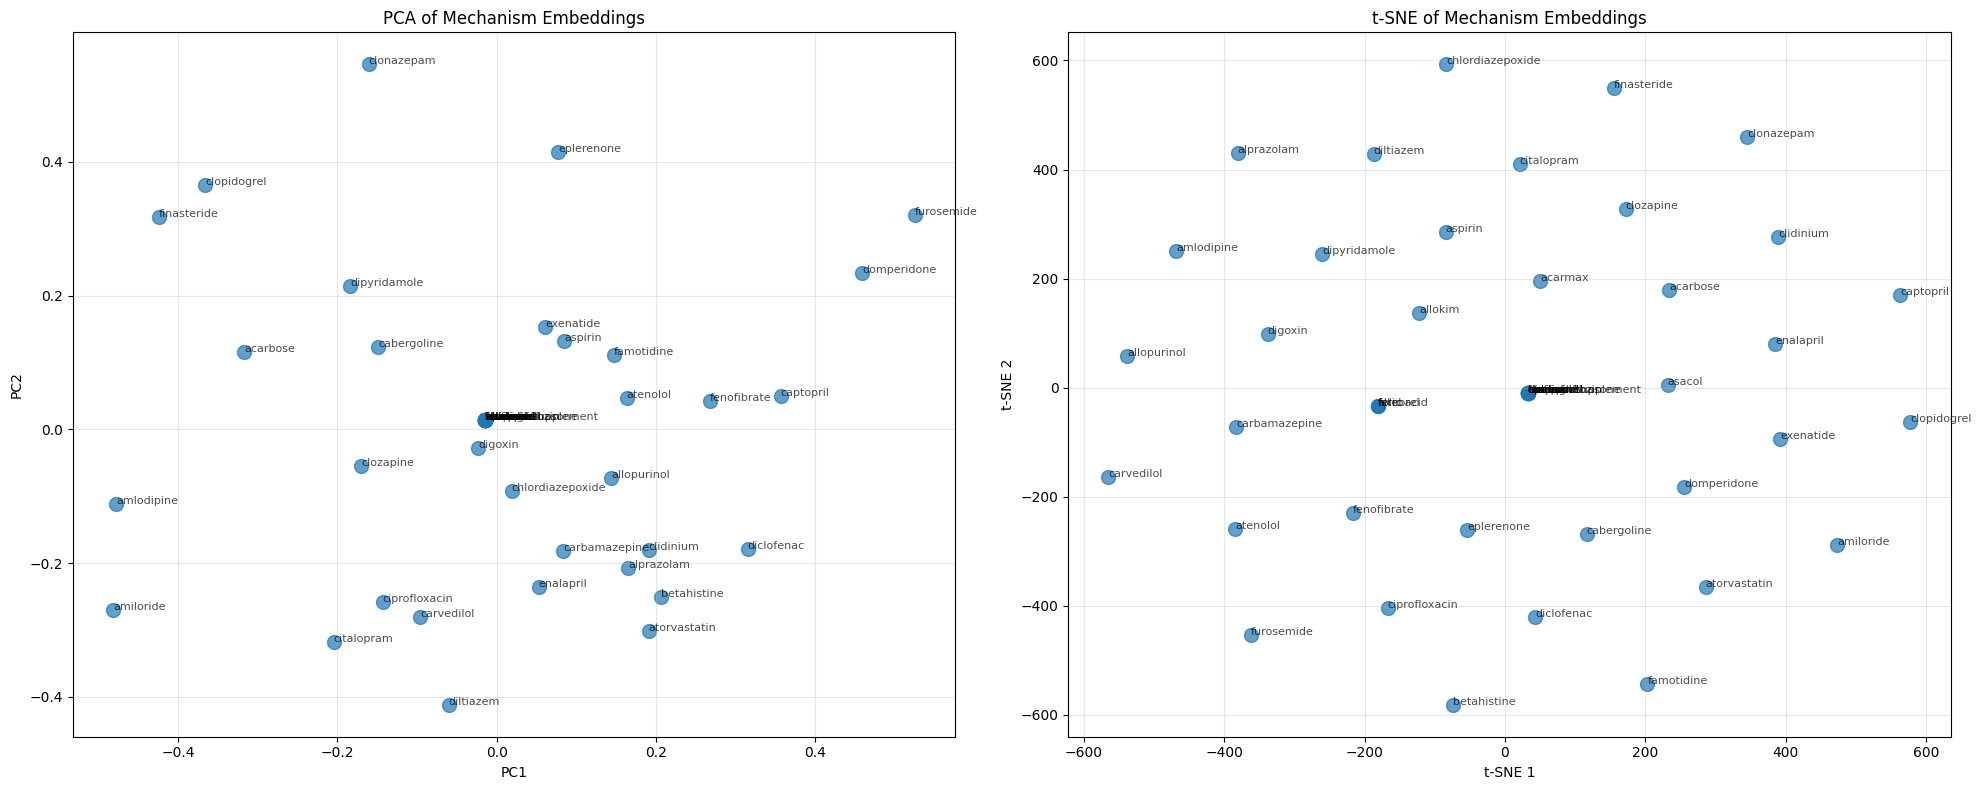

Clinical latents: (512, 128), Regimen latents: (512, 128)


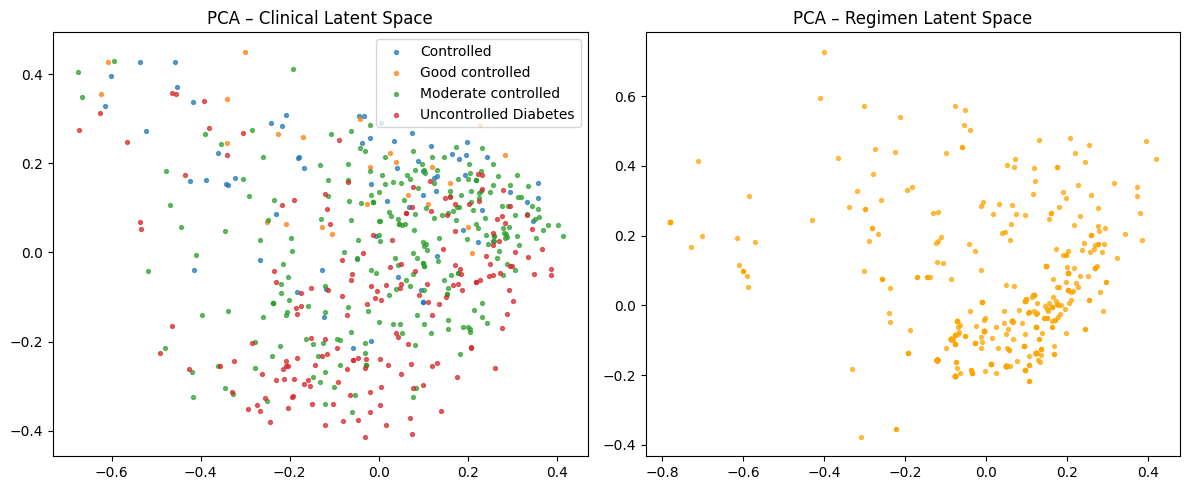

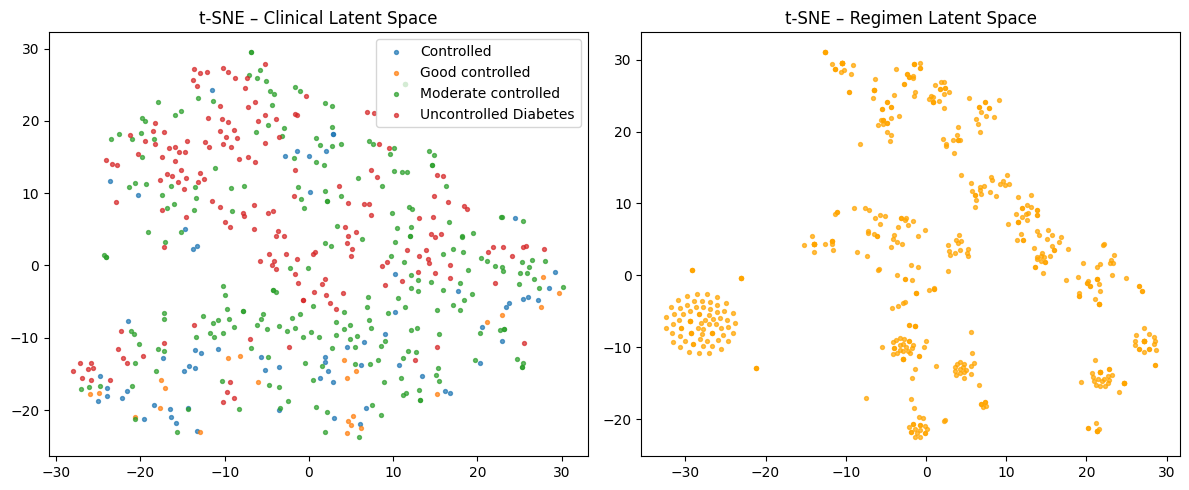

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


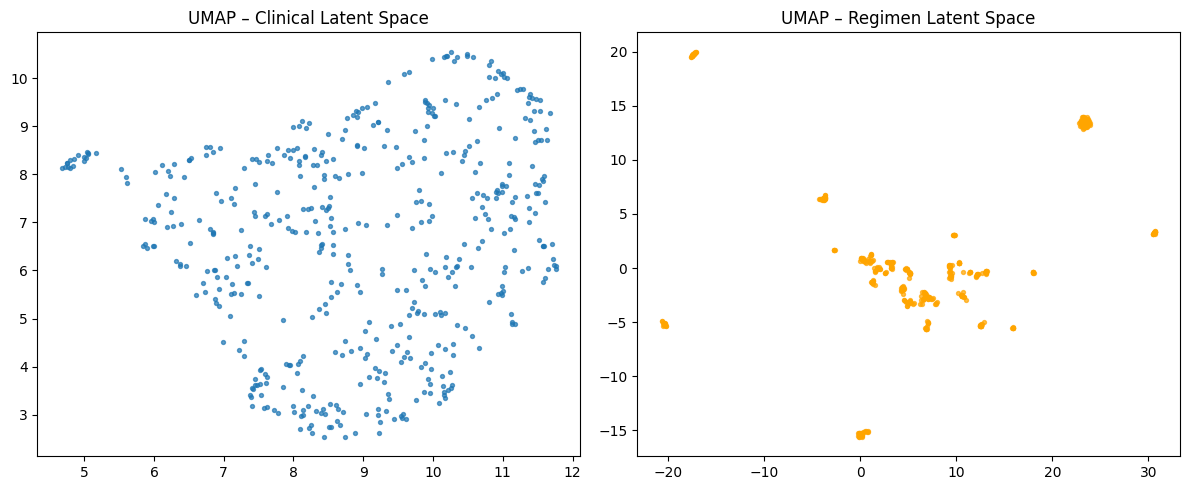


JOINT LATENT SPACE VISUALISATIONS


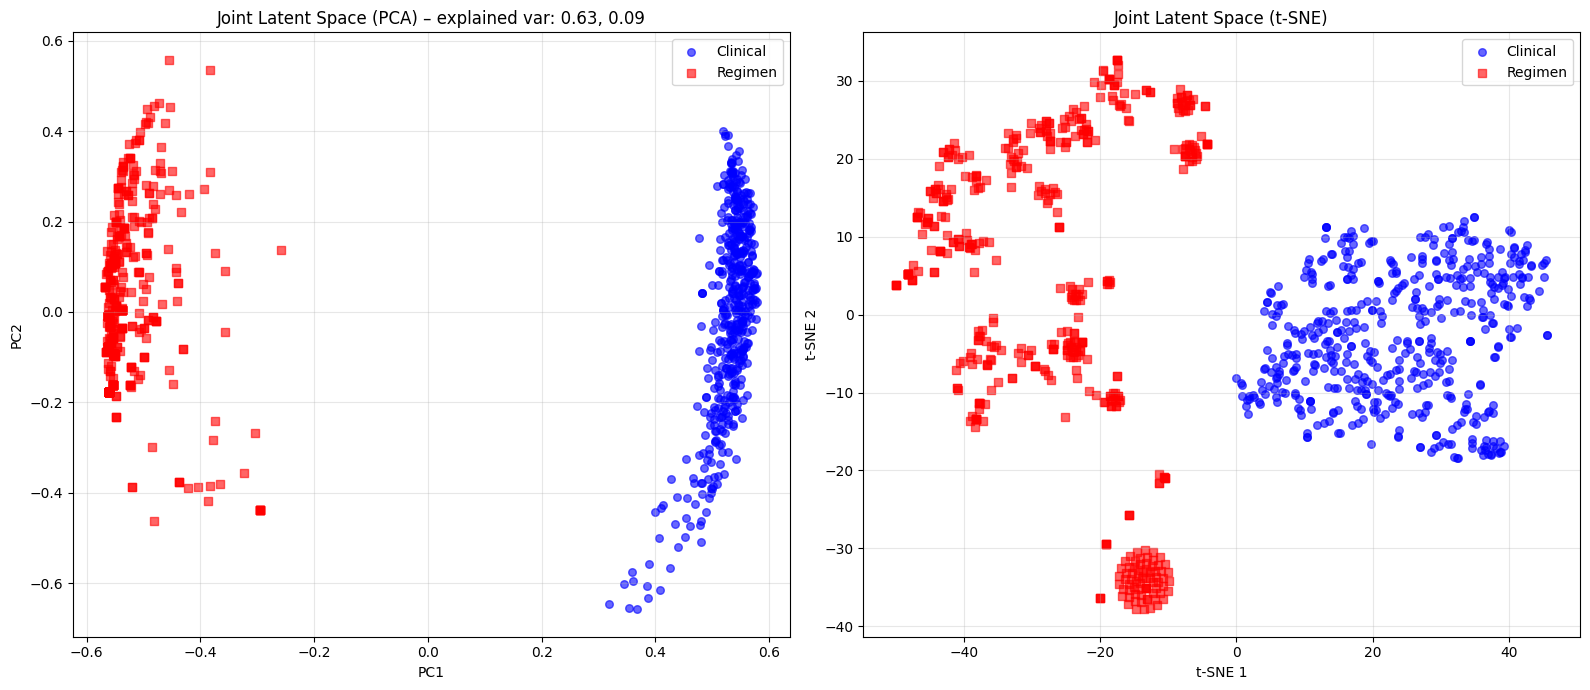

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


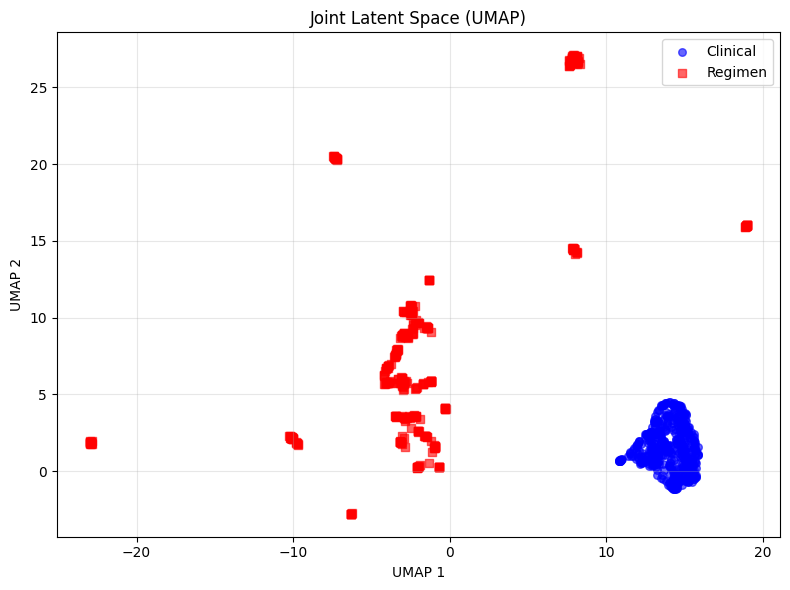

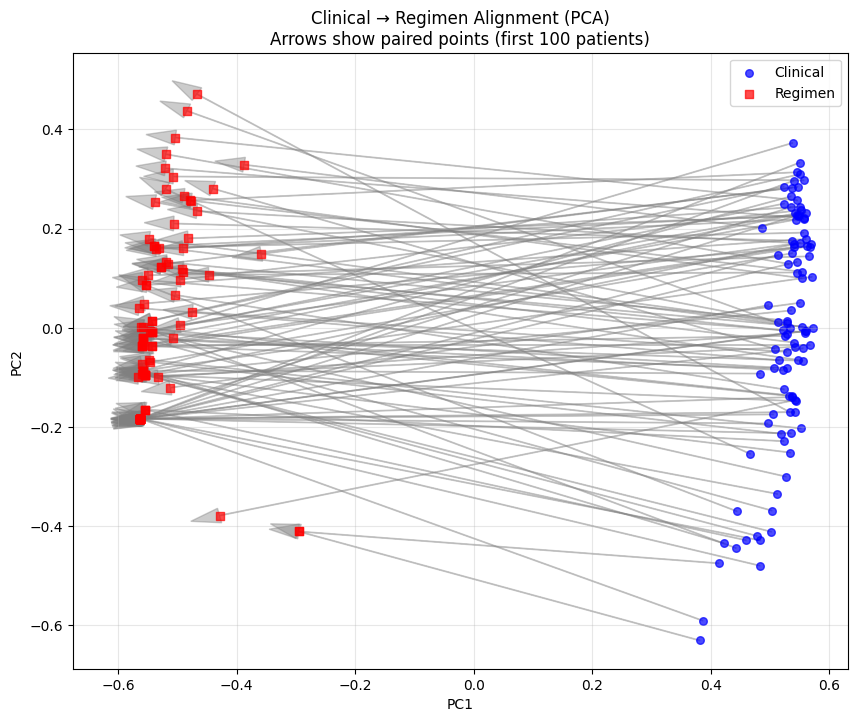

Mean PCA distance between clinical and regimen points: 1.080 ± 0.072

SELECT MODE:
  1. Interactive Demo (with mechanisms)
  2. Batch Report (with missed drug analysis)
  3. Exit

🧬 MAPCT-v5 | Complete Regimen Analysis

[1] Test  [2] Val  [3] Train  [4] Exit

📋 PATIENT 1

📊 CLINICAL:
   Age: 63 | HbA1c: 9.6% | FBS: 236
   LDL: 77 | HDL: 45 | TG: 58
   Control: Uncontrolled Diabetes

💊 ACTUAL REGIMEN: atorvastatin, metformin
   (2 drugs)
🎯 TOP PREDICTIONS: metformin, atorvastatin, aspirin, losartan, gliclazide
✅ MATCHED: metformin, atorvastatin (2/2)

📊 PREDICTED vs ACTUAL

Drug                      Predicted    Actual    
--------------------------------------------------
aspirin                   0.37                    🟡 EXTRA
atorvastatin              0.50         ✓          ✅ MATCH
gliclazide                0.32                    🟡 EXTRA
losartan                  0.32                    🟡 EXTRA
metformin                 0.77         ✓          ✅ MATCH

📋 RECOMMENDED REGIMEN: metfo

In [ ]:
# ============================================================
# MAIN EXECUTION (runs after training)
# ============================================================
!pip install umap-learn
if __name__ == "__main__":
    print("\n" + "="*60)
    print("🚀 MAPCT-v5 WITH MECHANISM ANALYSIS")
    print("="*60)

    # Load data (already done earlier, but included for completeness)
    from google.colab import drive
    drive.mount('/content/drive')

    file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
    file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

    clinic_df = pd.read_excel(file_path1, engine="openpyxl")
    mech_df = pd.read_excel(file_path2, engine="openpyxl")

    mech_df["Drug Name Norm"] = mech_df["Drug Name"].astype(str).apply(normalize_drug_name)

    numeric_cols = ["fbs", "glu", "hba1c", "TG", "cho", "LDL", "HDL", "UA", "Na", "K", "Ca", "Vit D", "age"]
    categorical_cols = ["sex", "fbs_category", "tg_category", "cho_category"]

    # Run full pipeline (training)
    trainer, scaler, ohe, drug_vocab, drug_to_idx, train_df, val_df, test_df, train_loader, test_loader, drug_embeddings = run_full_pipeline(
        clinic_df, mech_df, numeric_cols, categorical_cols)

    # ===== EVALUATION & VISUALISATIONS =====
    # 1. Compute drug metrics, alignment, diversity
    results = evaluate_mapct_v5(trainer, test_loader, device, threshold=0.3, compute_diversity=True)

    # 2. Visualise mechanism embeddings (drugs)
    visualize_mechanism_embeddings(drug_embeddings, drug_vocab, top_n=50)

    # 3. Visualise clinical and regimen latent spaces (PCA, t‑SNE, UMAP)
    visualize_v5_latents(trainer, test_loader, device, max_patients=500)

    # After your existing visualisations (inside __main__)
    print("\n" + "="*60)
    print("JOINT LATENT SPACE VISUALISATIONS")
    print("="*60)

    # 1. Joint latent space (clinical + regimen together)
    visualize_joint_latent_space(trainer, test_loader, device,
                                max_patients=500,
                                save_path='mapct_v5_joint_latent.png')

    # 2. Alignment arrows plot
    distances = visualize_alignment_arrows(trainer, test_loader, device,
                                          max_patients=100,
                                          save_path='mapct_v5_alignment_arrows.png')

    # ===== INTERACTIVE MODES =====
    print("\n" + "="*60)
    print("SELECT MODE:")
    print("  1. Interactive Demo (with mechanisms)")
    print("  2. Batch Report (with missed drug analysis)")
    print("  3. Exit")

    mode = input("\nChoice (1-3, default=1): ").strip() or "1"

    if mode == "1":
        enhanced_regimen_demo(
            trainer, scaler, ohe, drug_vocab,
            train_df, val_df, test_df,
            numeric_cols, categorical_cols, device,
            drug_embeddings, mech_df
        )
    elif mode == "2":
        df_results, insights = batch_report_with_mechanisms(
            trainer, scaler, ohe, drug_vocab,
            test_df, numeric_cols, categorical_cols, device,
            drug_embeddings, mech_df
        )
        save = input("\n💾 Save results? (y/n): ").strip().lower()
        if save == 'y':
            df_results.to_csv('/content/drive/MyDrive/khezri/regimen_results.csv', index=False)
            print("✅ Saved")
    else:
        print("\n✅ Exiting.")

    print("\n✅ MAPCT‑v5 complete.")